Dataset Loaded Successfully!
Total Vehicles: 30000

Median Estimated Range: 72.36 km

Range Class:
0 = Low Range
1 = High Range

Training Features: (24000, 7)
Testing Features: (6000, 7)
Training Target: (24000,)
Testing Target: (6000,)

Decision Tree Model Trained Successfully!

DECISION TREE EV RANGE MODEL
Median Range: 72.36 km
Accuracy: 95.77%

Actual vs Predicted Range Class
--------------------------------
    Actual Range Class  Predicted Range Class
0                    0                      0
1                    1                      1
2                    0                      0
3                    0                      0
4                    0                      0
5                    0                      0
6                    1                      1
7                    0                      1
8                    1                      1
9                    1                      1
10                   0                      1
11                   1          

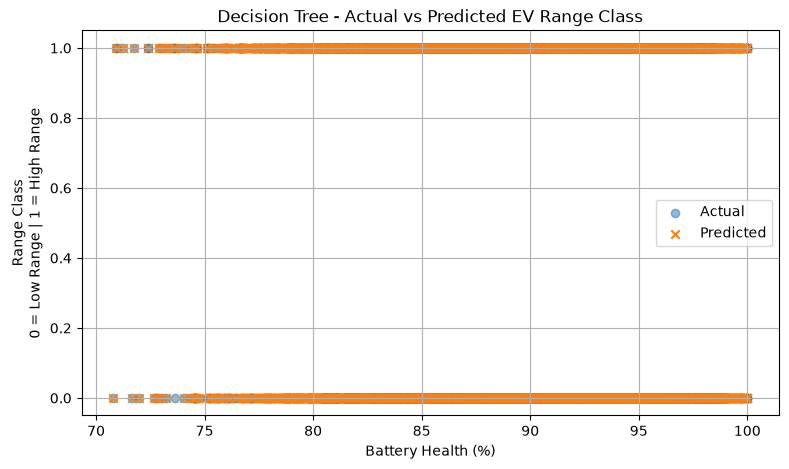

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv(
    r"preprocessed_data.csv"
)

print("Dataset Loaded Successfully!")
print("Total Vehicles:", len(df))

median_range = df["estimated_range_km"].median()

df["Range_Class"] = (
    df["estimated_range_km"] >= median_range
).astype(int)

print("\nMedian Estimated Range:",
      round(median_range, 2), "km")

print("\nRange Class:")
print("0 = Low Range")
print("1 = High Range")

X = df[
    [
        "battery_capacity_kwh",
        "state_of_charge",
        "battery_health",
        "energy_consumption_kwh_per_100km",
        "vehicle_age",
        "average_speed",
        "vehicle_weight_kg"
    ]
]

y = df["Range_Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully!")
y_pred = model.predict(X_test)
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n==============================")
print("DECISION TREE EV RANGE MODEL")
print("==============================")

print(
    "Median Range:",
    round(median_range, 2),
    "km"
)

print(
    "Accuracy:",
    f"{accuracy * 100:.2f}%"
)
result = pd.DataFrame({
    "Actual Range Class": y_test.values,
    "Predicted Range Class": y_pred
})

print("\nActual vs Predicted Range Class")
print("--------------------------------")

print(result.head(20))

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Range",
            "High Range"
        ]
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")
print("----------------")

print(cm)
plt.figure(figsize=(9, 5))

plt.scatter(
    X_test["battery_health"],
    y_test,
    label="Actual",
    alpha=0.5
)

plt.scatter(
    X_test["battery_health"],
    y_pred,
    marker="x",
    label="Predicted"
)

plt.title(
    "Decision Tree - Actual vs Predicted EV Range Class"
)

plt.xlabel("Battery Health (%)")

plt.ylabel(
    "Range Class\n0 = Low Range | 1 = High Range"
)

plt.legend()

plt.grid(True)

plt.show()